In [1]:
# Imports
import os
import numpy as np
import pandas as pd
import ast
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.collections import LineCollection
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
import matplotlib.animation as animation
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib import rcParams
from matplotlib.colors import LinearSegmentedColormap
from scipy.fft import fft, ifft, fftfreq

# Cardinal red theme for conference poster
CARDINAL_RED = '#8C1515'
CARDINAL_RED_LIGHT = '#B83A3A'
CARDINAL_RED_DARK = '#6B0F0F'
CARDINAL_PALETTE = [CARDINAL_RED, CARDINAL_RED_LIGHT, CARDINAL_RED_DARK, '#434343', '#6B6B6B']
sns.set_theme(style='whitegrid', palette=CARDINAL_PALETTE, font_scale=1.1)
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=CARDINAL_PALETTE)
TEXT_AND_OUTLINE = '#251F47'
plt.rcParams['axes.edgecolor'] = TEXT_AND_OUTLINE
plt.rcParams['axes.labelcolor'] = TEXT_AND_OUTLINE
plt.rcParams['text.color'] = TEXT_AND_OUTLINE
plt.rcParams['xtick.color'] = TEXT_AND_OUTLINE
plt.rcParams['ytick.color'] = TEXT_AND_OUTLINE
CARDINAL_CMAP = LinearSegmentedColormap.from_list('cardinal', ['#F5E6E6', CARDINAL_RED])
from scipy.signal import butter, filtfilt, find_peaks
from scipy.stats import linregress
from scipy.optimize import curve_fit
from scipy.signal import savgol_filter
from scipy.spatial import KDTree
from scipy.interpolate import interp1d

def read_csv_comments(file):
    # Read the CSV file, skipping comment lines
    metadata = {}
    with open(file, "r") as f:
        lines = f.readlines()
        # Separate comments (metadata) from actual data
        data_lines = []
        for line in lines:
            if line.startswith("#"):
                # Extract metadata from comment lines
                key, value = line[2:].strip().split(":", 1)
                metadata[key] = ast.literal_eval(value.strip())
            else:
                # Collect data lines (non-comment lines)
                data_lines.append(line)

    # Now read the CSV data into a DataFrame from the data lines
    from io import StringIO
    data_str = "".join(data_lines)  # Join the data lines back into a string
    df_read = pd.read_csv(StringIO(data_str))

    # Attach the metadata back to the DataFrame
    df_read.attrs = metadata
    return df_read

# Helper function to find first significant change
def find_first_significant_change(values, threshold_std=1.0, min_change=None):
    """
    Find the first index where the value changes significantly from baseline.
    Uses either a threshold based on std or a minimum change value.
    """
    if len(values) < 10:
        return 0
    
    # Calculate baseline (mean of first portion of data)
    baseline_length = min(10, len(values) // 10)
    baseline = np.nanmean(values[:baseline_length])
    baseline_std = np.nanstd(values[:baseline_length])
    
    # Determine threshold
    if min_change is None:
        threshold = threshold_std * baseline_std
    else:
        threshold = min_change
    
    # Find first point where change exceeds threshold
    for i in range(baseline_length, len(values)):
        if not np.isnan(values[i]):
            change = abs(values[i] - baseline)
            if change > threshold:
                return i
    
    return 0  # If no significant change found, return 0


In [124]:
current_file = '050226_L'
video_df = read_csv_comments('/Volumes/Dragonfly3D/Tplax_data/050226/'+current_file+'_raw.csv')
serial_df = read_csv_comments('/Volumes/Dragonfly3D/Tplax_data/050226/'+current_file+'.csv')


# 1D

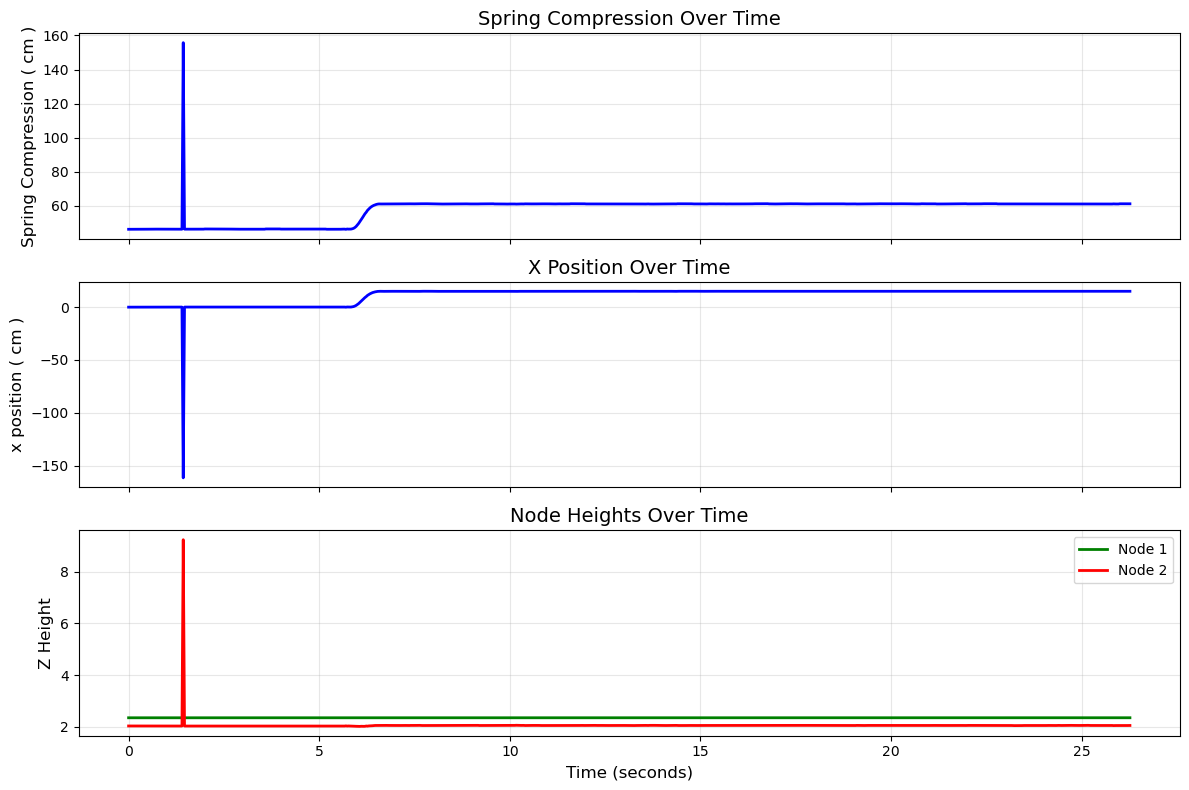

In [125]:
# Extract data for each node by frame
fps = 30
frames = video_df['frame#'].unique()
frames_sorted = np.sort(frames)

# Initialize arrays
time = frames_sorted / fps
spring_compression = []
z_node1 = []
z_node2 = []
xpos = []

# Calculate spring compression and z heights for each frame
for frame in frames_sorted:
    frame_data = video_df[video_df['frame#'] == frame]
    
    # Get positions for each node
    node1_data = frame_data[frame_data['node_id'] == 1]
    node2_data = frame_data[frame_data['node_id'] == 2]
    
    if len(node1_data) > 0 and len(node2_data) > 0:
        # Extract positions
        x1, y1, z1 = node1_data.iloc[0][['x', 'y', 'z']].values
        x2, y2, z2 = node2_data.iloc[0][['x', 'y', 'z']].values
        
        # Calculate spring compression (distance in x/y plane)
        compression = 100. * np.sqrt((x2 - x1)**2 + (y2 - y1)**2) # convert to cm
        spring_compression.append(compression)
        
        # Store z heights
        z_node1.append(z1)
        z_node2.append(z2)
        xpos.append(100*x2)
    else:
        # Handle missing data
        spring_compression.append(np.nan)
        z_node1.append(np.nan)
        z_node2.append(np.nan)
        xpos.append(np.nan)

spring_compression = np.array(spring_compression)
z_node1 = np.array(z_node1)
z_node2 = np.array(z_node2)
xpos = np.array(xpos)
xpos = xpos - xpos[0]

# Create two vertically stacked subplots with shared x-axis
fig, (ax1, ax3,ax2) = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# Plot 1: Spring compression
ax1.plot(time, spring_compression, linewidth=2, color=CARDINAL_RED)
ax1.set_ylabel('Spring Compression ( cm )', fontsize=12)
ax1.set_title('Spring Compression Over Time', fontsize=14)
ax1.grid(True, alpha=0.3)

ax3.plot(time, xpos, linewidth=2, color=CARDINAL_RED)
ax3.set_ylabel('x position ( cm )', fontsize=12)
ax3.set_title('X Position Over Time', fontsize=14)
ax3.grid(True, alpha=0.3)

# Plot 2: Z heights
ax2.plot(time, z_node1, label='Node 1', linewidth=2, color=CARDINAL_RED)
ax2.plot(time, z_node2, label='Node 2', linewidth=2, color=CARDINAL_RED_LIGHT)
ax2.set_xlabel('Time (seconds)', fontsize=12)
ax2.set_ylabel('Z Height', fontsize=12)
ax2.set_title('Node Heights Over Time', fontsize=14)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Mean time difference between samples: 0.010005 seconds (10.005 ms)
Std time difference between samples: 0.000224 seconds (0.224 ms)


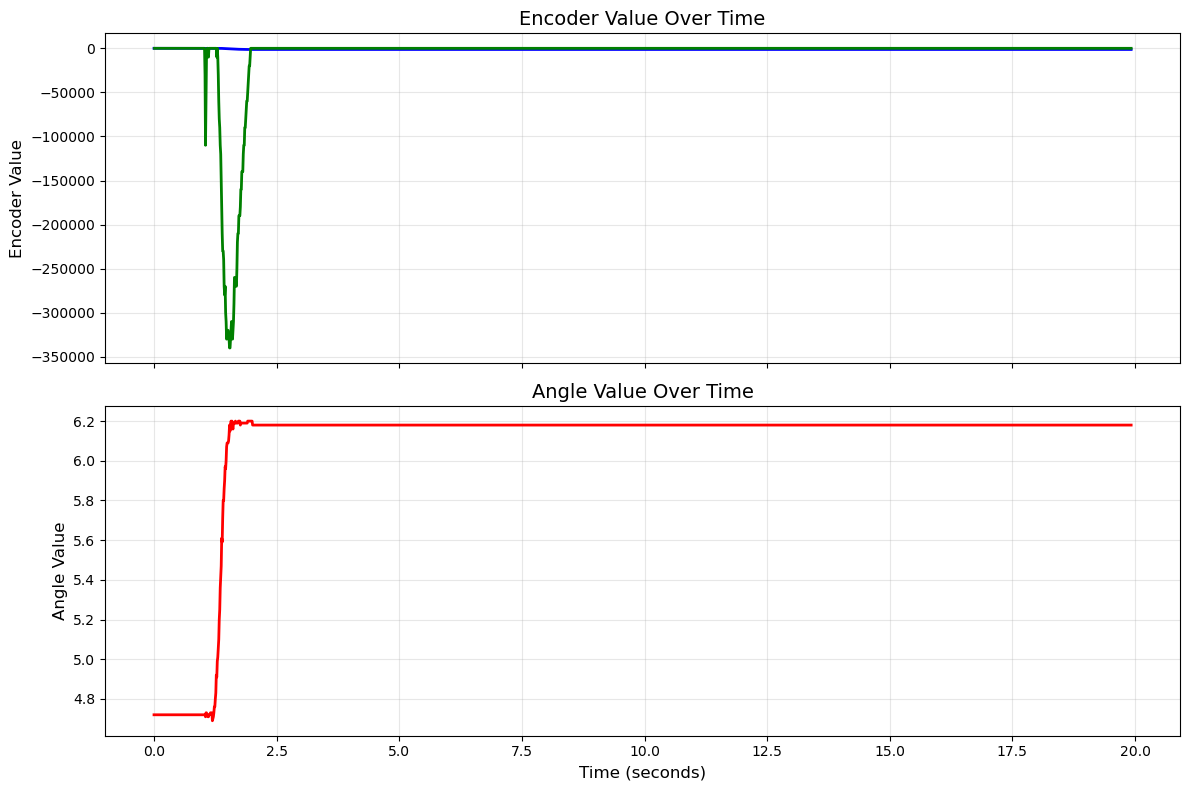

In [126]:
# Process serial_df timestamps
# Convert timestamp (seconds + microseconds) to time array starting at 0
# Find timestamp columns (could be 'timestamp', 'timestamp_s', 'timestamp_us', etc.)
serial_df = serial_df.iloc[1:] # missed some values in first timestamp

cols = serial_df.columns.tolist()



timestamp_total = serial_df['timestamp_s'] + serial_df['timestamp_us'] / 1e6

# Convert to time array starting at 0
time_serial = timestamp_total - timestamp_total.iloc[0]

# Calculate time differences between samples
time_diffs = np.diff(time_serial.values)
mean_dt = np.mean(time_diffs)
std_dt = np.std(time_diffs)

print(f"Mean time difference between samples: {mean_dt:.6f} seconds ({mean_dt*1000:.3f} ms)")
print(f"Std time difference between samples: {std_dt:.6f} seconds ({std_dt*1000:.3f} ms)")

# Extract encoder_value and angle_value
encoder_value = serial_df['encoder_value'].values
encoder_value = encoder_value - encoder_value[0]
angle_value = serial_df['angle_value'].values

# Create two vertically stacked subplots with shared x-axis
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Plot 1: Encoder value
ax1.plot( time_serial, encoder_value, linewidth=2, color=CARDINAL_RED)
ax1.plot( time_serial[1:], 10000*np.diff(encoder_value), linewidth=2, color=CARDINAL_RED_LIGHT)
ax1.set_ylabel('Encoder Value', fontsize=12)
ax1.set_title('Encoder Value Over Time', fontsize=14)
ax1.grid(True, alpha=0.3)

# Plot 2: Angle value
ax2.plot( time_serial, angle_value, linewidth=2, color=CARDINAL_RED)
ax2.set_xlabel('Time (seconds)', fontsize=12)
ax2.set_ylabel('Angle Value', fontsize=12)
ax2.set_title('Angle Value Over Time', fontsize=14)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [127]:
# Synchronize video_df and serial_df datasets
# Find first significant change in encoder_value and xpos, then align them

# Helper function to find first significant change
def find_first_significant_change(values, threshold_std=1.0, min_change=None):
    """
    Find the first index where the value changes significantly from baseline.
    Uses either a threshold based on std or a minimum change value.
    """
    if len(values) < 10:
        return 0
    
    # Calculate baseline (mean of first portion of data)
    baseline_length = min(10, len(values) // 10)
    baseline = np.nanmean(values[:baseline_length])
    baseline_std = np.nanstd(values[:baseline_length])
    
    # Determine threshold
    if min_change is None:
        threshold = threshold_std * baseline_std
    else:
        threshold = min_change
    
    # Find first point where change exceeds threshold
    for i in range(baseline_length, len(values)):
        if not np.isnan(values[i]):
            change = abs(values[i] - baseline)
            if change > threshold:
                return i
    
    return 0  # If no significant change found, return 0

# Find first significant changes
encoder_first_change_idx = find_first_significant_change(encoder_value, threshold_std=2.0, min_change=2)
xpos_first_change_idx = find_first_significant_change(xpos, threshold_std=100.0)

print(f"First significant change in encoder_value at index {encoder_first_change_idx} (time: {time_serial.values[encoder_first_change_idx]:.3f} s)")
print(f"First significant change in xpos at index {xpos_first_change_idx} (time: {time[xpos_first_change_idx]:.3f} s)")

# Calculate time offset to align the two events
time_offset = time_serial.values[encoder_first_change_idx] - time[xpos_first_change_idx]
print(f"Time offset to align events: {time_offset:.3f} s")

# Adjust serial time by the offset
time_serial_aligned = (time_serial - time_offset).values

# Create common time base (use intersection of both time ranges)
time_min = max(time_serial_aligned.min(), time.min())
time_max = min(time_serial_aligned.max(), time.max())
# Use the finer sampling rate (serial data appears to be ~10Hz, video is 30Hz)
# But let's use a reasonable sampling rate that captures both
dt_common = min(1.0/30.0, np.nanmean(np.diff(time_serial_aligned)))  # Use finer of the two
time_common = np.arange(time_min, time_max, dt_common)

print(f"Common time base: {len(time_common)} points from {time_min:.3f} to {time_max:.3f} s (dt={dt_common:.4f} s)")

# Interpolate all data to common time base
# Remove NaN values before interpolation
valid_mask_video = ~(np.isnan(xpos) | np.isnan(spring_compression) | np.isnan(z_node1) | np.isnan(z_node2))
valid_mask_serial = ~(np.isnan(encoder_value) | np.isnan(angle_value))

time_video_valid = time[valid_mask_video]
time_serial_valid = time_serial_aligned[valid_mask_serial]

# Interpolate video data
xpos_interp = interp1d(time_video_valid, xpos[valid_mask_video], 
                       kind='linear', bounds_error=False, fill_value=np.nan)(time_common)
spring_compression_interp = interp1d(time_video_valid, spring_compression[valid_mask_video], 
                                     kind='linear', bounds_error=False, fill_value=np.nan)(time_common)
z_node1_interp = interp1d(time_video_valid, z_node1[valid_mask_video], 
                          kind='linear', bounds_error=False, fill_value=np.nan)(time_common)
z_node2_interp = interp1d(time_video_valid, z_node2[valid_mask_video], 
                          kind='linear', bounds_error=False, fill_value=np.nan)(time_common)

# Interpolate serial data
encoder_value_interp = interp1d(time_serial_valid, encoder_value[valid_mask_serial], 
                                kind='linear', bounds_error=False, fill_value=np.nan)(time_common)
angle_value_interp = interp1d(time_serial_valid, angle_value[valid_mask_serial], 
                              kind='linear', bounds_error=False, fill_value=np.nan)(time_common)

# Create encoder_angle (assuming it's the same as encoder_value, or check if column exists)
if 'encoder_angle' in serial_df.columns:
    encoder_angle = serial_df['encoder_angle'].values
    encoder_angle_interp = interp1d(time_serial_valid, encoder_angle[valid_mask_serial], 
                                     kind='linear', bounds_error=False, fill_value=np.nan)(time_common)
else:
    # Use encoder_value as encoder_angle
    encoder_angle_interp = encoder_value_interp.copy()

print(f"\nInterpolated arrays created (all on common time base 'time_common'):")
print(f"  time_common: {len(time_common)} points")
print(f"  xpos_interp: {len(xpos_interp)} points")
print(f"  spring_compression_interp: {len(spring_compression_interp)} points")
print(f"  z_node1_interp: {len(z_node1_interp)} points")
print(f"  z_node2_interp: {len(z_node2_interp)} points")
print(f"  encoder_angle_interp: {len(encoder_angle_interp)} points")
print(f"  angle_value_interp: {len(angle_value_interp)} points")

First significant change in encoder_value at index 103 (time: 1.040 s)
First significant change in xpos at index 43 (time: 1.433 s)
Time offset to align events: -0.393 s
Common time base: 1991 points from 0.393 to 20.313 s (dt=0.0100 s)

Interpolated arrays created (all on common time base 'time_common'):
  time_common: 1991 points
  xpos_interp: 1991 points
  spring_compression_interp: 1991 points
  z_node1_interp: 1991 points
  z_node2_interp: 1991 points
  encoder_angle_interp: 1991 points
  angle_value_interp: 1991 points


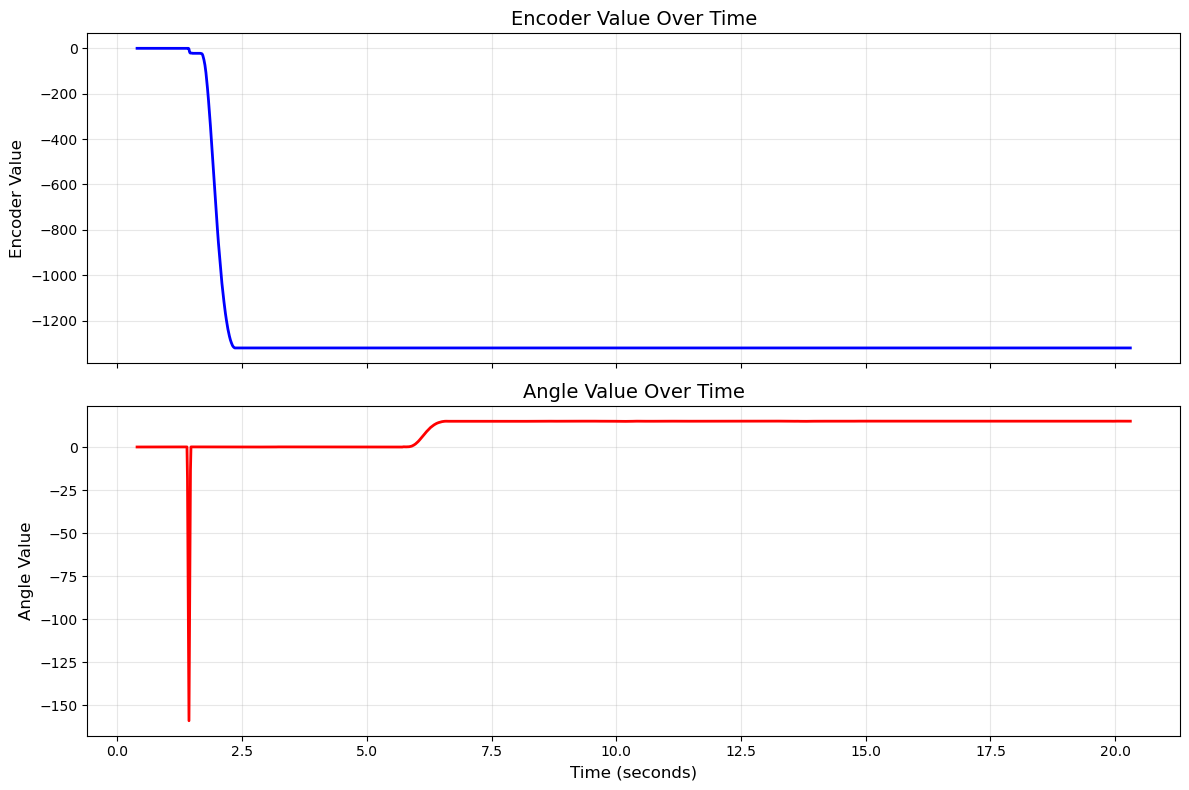

In [128]:
# Create two vertically stacked subplots with shared x-axis
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Plot 1: Encoder value
ax1.plot(time_common, encoder_value_interp, linewidth=2, color=CARDINAL_RED)
ax1.set_ylabel('Encoder Value', fontsize=12)
ax1.set_title('Encoder Value Over Time', fontsize=14)
ax1.grid(True, alpha=0.3)

# Plot 2: Angle value
ax2.plot(time_common, xpos_interp, linewidth=2, color=CARDINAL_RED_LIGHT)
ax2.set_xlabel('Time (seconds)', fontsize=12)
ax2.set_ylabel('Angle Value', fontsize=12)
ax2.set_title('Angle Value Over Time', fontsize=14)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

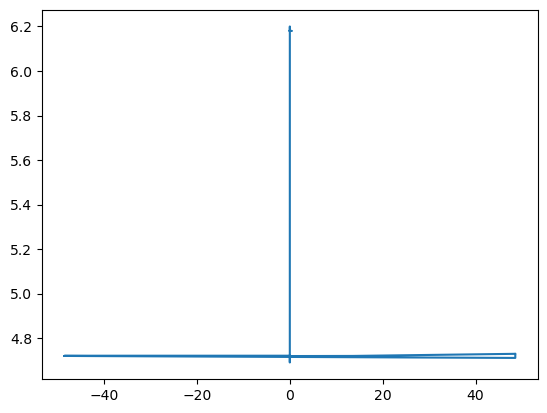

In [129]:
plt.plot(np.diff(xpos_interp), angle_value_interp[1:], color=CARDINAL_RED, linewidth=2)

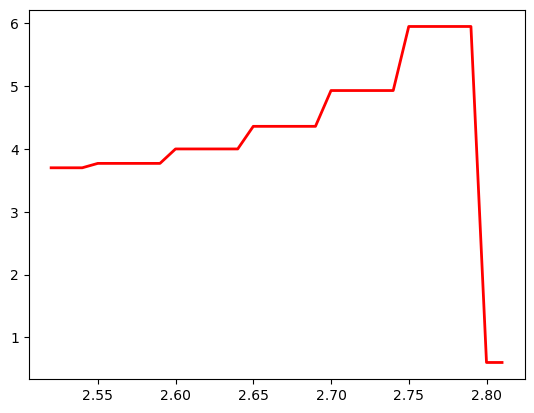

In [96]:
plt.plot(time_serial[250:280], angle_value[250:280], linewidth=2, color=CARDINAL_RED)

In [97]:
angle_value[250:280]

array([3.7 , 3.7 , 3.7 , 3.77, 3.77, 3.77, 3.77, 3.77, 4.  , 4.  , 4.  ,
       4.  , 4.  , 4.36, 4.36, 4.36, 4.36, 4.36, 4.93, 4.93, 4.93, 4.93,
       4.93, 5.95, 5.95, 5.95, 5.95, 5.95, 0.6 , 0.6 ])

In [40]:
time[173]

np.float64(5.766666666666667)

In [80]:
angle_value

array([0.53, 0.53, 0.53, ..., 3.97, 3.97, 3.97], shape=(5989,))

# 2D

In [2]:
# Aggregate data from multiple files
# Handle multiple dates: 090226 and 100226
data_base = '/Users/alexleffell/Documents/PhD/tplax/Data'
dates = ['090226', '100226']

# Read label maps for all dates and combine
all_label_maps = []
for date in dates:
    data_folder = os.path.join(data_base, date)
    label_map_path = os.path.join(data_folder, f'{date}_label_map.csv')
    
    if os.path.exists(label_map_path):
        label_map = pd.read_csv(label_map_path)
        label_map['date'] = date  # Add date column to track which date
        all_label_maps.append(label_map)
        print(f"Found {len(label_map)} experiments in {date} label map")
    else:
        print(f"Warning: {label_map_path} not found")

# Combine all label maps
if len(all_label_maps) > 0:
    label_map = pd.concat(all_label_maps, ignore_index=True)
    # Filter out rows with empty IDs
    label_map = label_map[label_map['ID'].notna() & (label_map['ID'] != '')]
    print(f"\nTotal experiments across all dates: {len(label_map)}")
    print(f"Sample IDs: {label_map[['date', 'ID']].head(10)}")
else:
    print("No label maps found!")
    label_map = pd.DataFrame()

Found 42 experiments in 090226 label map
Found 44 experiments in 100226 label map

Total experiments across all dates: 80
Sample IDs:      date   ID
0  090226   A1
1  090226   A2
2  090226   A3
3  090226   A4
4  090226   A5
5  090226   A6
6  090226   A7
7  090226   A8
8  090226   A9
9  090226  A10


In [3]:
# Helper function to transform node 2 position to reference frame
# Reference frame: node 1 at origin, node 1->node 3 defines x-axis
def transform_to_reference_frame(video_df, fps=30):
    """
    Transform node positions to reference frame where:
    - Node 1 is at origin
    - Vector from node 1 to node 3 defines x-axis
    - Extract node 2's x/y position in this frame
    """
    frames = video_df['frame#'].unique()
    frames_sorted = np.sort(frames)
    
    time = frames_sorted / fps
    x_positions = []
    y_positions = []
    
    for frame in frames_sorted:
        frame_data = video_df[video_df['frame#'] == frame]
        
        # Get positions for each node
        node1_data = frame_data[frame_data['node_id'] == 1]
        node2_data = frame_data[frame_data['node_id'] == 2]
        node3_data = frame_data[frame_data['node_id'] == 3]
        
        if len(node1_data) > 0 and len(node2_data) > 0 and len(node3_data) > 0:
            # Extract positions
            x1, y1, z1 = node1_data.iloc[0][['x', 'y', 'z']].values
            x2, y2, z2 = node2_data.iloc[0][['x', 'y', 'z']].values
            x3, y3, z3 = node3_data.iloc[0][['x', 'y', 'z']].values
            
            # Translate so node 1 is at origin
            x2_translated = x2 - x1
            y2_translated = y2 - y1
            x3_translated = x3 - x1
            y3_translated = y3 - y1
            
            # Calculate angle from node 1 to node 3 (x-axis direction)
            theta = np.arctan2(y3_translated, x3_translated)
            
            # Rotate by -theta to align x-axis
            cos_theta = np.cos(-theta)
            sin_theta = np.sin(-theta)
            
            # Rotation matrix: [cos(-theta), -sin(-theta); sin(-theta), cos(-theta)]
            x2_rotated = cos_theta * x2_translated - sin_theta * y2_translated
            y2_rotated = sin_theta * x2_translated + cos_theta * y2_translated
            
            x_positions.append(x2_rotated)
            y_positions.append(y2_rotated)
        else:
            x_positions.append(np.nan)
            y_positions.append(np.nan)
    
    # Create dataframe
    df = pd.DataFrame({
        'time': time,
        'x': x_positions,
        'y': y_positions
    })
    
    return df

In [4]:
# Process all files and aggregate data
all_experiments = []

for idx, row in label_map.iterrows():
    file_id = str(row['ID'])
    date = str(row['date'])  # Get the date for this experiment
    data_folder = os.path.join(data_base, date)
    
    # Construct file paths - try both single and double underscore patterns
    raw_file = os.path.join(data_folder, f'{date}_{file_id}_raw.csv')
    csv_file = os.path.join(data_folder, f'{date}_{file_id}.csv')
    
    # Try double underscore if single doesn't exist
    if not os.path.exists(raw_file):
        raw_file = os.path.join(data_folder, f'{date}__{file_id}_raw.csv')
    if not os.path.exists(csv_file):
        csv_file = os.path.join(data_folder, f'{date}__{file_id}.csv')
    
    # Check if both files exist
    if not os.path.exists(raw_file):
        print(f"Warning: {date}_{file_id}_raw.csv not found (tried both patterns), skipping {file_id}")
        continue
    if not os.path.exists(csv_file):
        print(f"Warning: {date}_{file_id}.csv not found (tried both patterns), skipping {file_id}")
        continue
    
    try:
        # Process video data (_raw.csv)
        video_df = read_csv_comments(raw_file)
        video_data = transform_to_reference_frame(video_df, fps=30)

        # Apply median filter to video data (remove outliers)
        for col in ['x', 'y']:
            if col in video_data.columns:
                video_data[col] = video_data[col].rolling(window=3, center=True, min_periods=1).median()
        
        # Process encoder/angle data (.csv)
        serial_df = read_csv_comments(csv_file)
        # Skip first row if it has bad timestamp (as in existing code)
        if len(serial_df) > 1:
            serial_df = serial_df.iloc[1:].copy()
        
        # Combine timestamps
        timestamp_total = serial_df['timestamp_s'] + serial_df['timestamp_us'] / 1e6
        time_serial = timestamp_total - timestamp_total.iloc[0]
        
        # Process encoder value (shift and rename)
        encoder_value = serial_df['encoder_value'].values
        wheel_angle = encoder_value - encoder_value[0]
        
        # Rename angle_value to heading
        heading = serial_df['angle_value'].values
        
        # Create encoder dataframe
        encoder_data = pd.DataFrame({
            'time': time_serial.values,
            'wheel_angle': wheel_angle,
            'heading': heading
        })

        # # Apply median filter to encoder data (remove outliers)
        # for col in ['wheel_angle', 'heading']:
        #     if col in encoder_data.columns:
        #         encoder_data[col] = encoder_data[col].rolling(window=3, center=True, min_periods=1).median()
        
        # Store for alignment
        all_experiments.append({
            'file_id': file_id,
            'date': date,  # Store date for reference
            'video_data': video_data,
            'encoder_data': encoder_data,
            'params': row.to_dict()
        })
        
        print(f"Processed {date}_{file_id}: video {len(video_data)} points, encoder {len(encoder_data)} points")
        
    except Exception as e:
        print(f"Error processing {file_id}: {e}")
        continue

print(f"\nSuccessfully processed {len(all_experiments)} experiments")

Processed 090226_A1: video 478 points, encoder 992 points
Processed 090226_A2: video 2097 points, encoder 5993 points
Processed 090226_A3: video 573 points, encoder 993 points
Processed 090226_A4: video 2040 points, encoder 5991 points
Processed 090226_A5: video 586 points, encoder 993 points
Processed 090226_A6: video 2099 points, encoder 5992 points
Processed 090226_A7: video 513 points, encoder 992 points
Processed 090226_A8: video 2060 points, encoder 5992 points
Processed 090226_A9: video 614 points, encoder 992 points
Processed 090226_A10: video 2023 points, encoder 5993 points
Processed 090226_A11: video 497 points, encoder 991 points
Processed 090226_A12: video 1963 points, encoder 5992 points
Processed 090226_A13: video 473 points, encoder 992 points
Processed 090226_A14: video 1998 points, encoder 5991 points
Processed 090226_A15: video 523 points, encoder 993 points
Processed 090226_A16: video 2029 points, encoder 5990 points
Processed 090226_B1: video 2058 points, encoder 5

In [5]:
# Align time series and interpolate to common timebase for each experiment
aligned_experiments = []

for exp in all_experiments:
    file_id = exp['file_id']
    video_data = exp['video_data']
    encoder_data = exp['encoder_data']
    
    try:
        # Find first significant changes
        # Use x position from video data
        x_values = video_data['x'].values
        wheel_angle_values = encoder_data['wheel_angle'].values
        
        # Remove NaN values for finding significant change
        valid_x = ~np.isnan(x_values)
        valid_wheel = ~np.isnan(wheel_angle_values)
        
        if np.sum(valid_x) < 10 or np.sum(valid_wheel) < 10:
            print(f"Warning: {file_id} has insufficient valid data, skipping alignment")
            continue
        
        x_first_change_idx = find_first_significant_change(x_values, threshold_std=2.0)
        wheel_first_change_idx = find_first_significant_change(wheel_angle_values, threshold_std=2.0, min_change=2)
        
        # Get times at these indices
        video_time = video_data['time'].values
        encoder_time = encoder_data['time'].values
        
        if x_first_change_idx >= len(video_time) or wheel_first_change_idx >= len(encoder_time):
            print(f"Warning: {file_id} has invalid change indices, skipping")
            continue
        
        time_video_change = video_time[x_first_change_idx]
        time_encoder_change = encoder_time[wheel_first_change_idx]
        
        # Calculate time offset to align events
        time_offset = time_encoder_change - time_video_change
        
        # Adjust encoder time by offset
        encoder_time_aligned = encoder_time - time_offset
        
        # Create common time base
        time_min = max(encoder_time_aligned.min(), video_time.min())
        time_max = min(encoder_time_aligned.max(), video_time.max())
        
        # Use finer sampling rate
        dt_video = np.nanmean(np.diff(video_time)) if len(video_time) > 1 else 1.0/30.0
        dt_encoder = np.nanmean(np.diff(encoder_time)) if len(encoder_time) > 1 else 0.01
        dt_common = min(dt_video, dt_encoder)
        
        time_common = np.arange(time_min, time_max, dt_common)
        
        if len(time_common) == 0:
            print(f"Warning: {file_id} has no overlap in time ranges, skipping")
            continue
        
        # Interpolate video data
        valid_mask_video = ~(np.isnan(x_values) | np.isnan(video_data['y'].values))
        time_video_valid = video_time[valid_mask_video]
        x_valid = x_values[valid_mask_video]
        y_valid = video_data['y'].values[valid_mask_video]
        
        x_interp = interp1d(time_video_valid, x_valid, 
                            kind='linear', bounds_error=False, fill_value=np.nan)(time_common)
        y_interp = interp1d(time_video_valid, y_valid, 
                            kind='linear', bounds_error=False, fill_value=np.nan)(time_common)
        
        # Interpolate encoder data
        valid_mask_encoder = ~(np.isnan(wheel_angle_values) | np.isnan(encoder_data['heading'].values))
        time_encoder_valid = encoder_time_aligned[valid_mask_encoder]
        wheel_angle_valid = wheel_angle_values[valid_mask_encoder]
        heading_valid = encoder_data['heading'].values[valid_mask_encoder]
        
        wheel_angle_interp = interp1d(time_encoder_valid, wheel_angle_valid, 
                                      kind='linear', bounds_error=False, fill_value=np.nan)(time_common)
        heading_interp = interp1d(time_encoder_valid, heading_valid, 
                                 kind='linear', bounds_error=False, fill_value=np.nan)(time_common)
        
        # Create a single row dictionary with lists for time series
        experiment_row = {
            'file_id': file_id,
            'date': exp['date'],  # Include date
            'time': time_common.tolist(),
            'x': x_interp.tolist(),
            'y': y_interp.tolist(),
            'wheel_angle': wheel_angle_interp.tolist(),
            'heading': heading_interp.tolist()
        }
        
        # Add experiment parameters
        for key, value in exp['params'].items():
            experiment_row[key] = value
        
        aligned_experiments.append(experiment_row)
        
    except Exception as e:
        print(f"Error aligning {file_id}: {e}")
        import traceback
        traceback.print_exc()
        continue

print(f"\nSuccessfully aligned {len(aligned_experiments)} experiments")


Successfully aligned 44 experiments


/var/folders/30/gfnvy8ms33q6k0hcsvgz7x6c0000gn/T/ipykernel_50711/2902883585.py:75: RuntimeWarning: Mean of empty slice
  baseline = np.nanmean(values[:baseline_length])
/opt/miniconda3/envs/tplax_env/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [6]:
# Combine all experiments into single dataframe (one row per experiment)
if len(aligned_experiments) > 0:
    combined_data = pd.DataFrame(aligned_experiments)
    
    # Add new columns: angular velocity stats, polar coordinates, and peak metrics
    omega_mean_list = []
    omega_std_list = []
    mean_radius_list = []
    peak_omega_list = []
    time_to_zero_list = []
    
    for idx, row in combined_data.iterrows():
        # Extract time series
        time = np.array(row['time'])
        x = np.array(row['x'])
        y = np.array(row['y'])
        heading = np.array(row['heading'])
        
        # Remove NaN values
        valid_mask = ~(np.isnan(time) | np.isnan(x) | np.isnan(y) | np.isnan(heading))
        time_valid = time[valid_mask]
        x_valid = x[valid_mask]
        y_valid = y[valid_mask]
        heading_valid = heading[valid_mask]
        
        # 1. Compute angular velocity (mean and std)
        if len(time_valid) > 1 and len(heading_valid) > 1:
            # Map heading to [-pi, pi] then unwrap
            heading_centered = (heading_valid + np.pi) % (2 * np.pi) - np.pi
            heading_unwrapped = np.unwrap(heading_centered)
            
            # Compute angular velocity
            dt = np.diff(time_valid)
            dtheta = np.diff(heading_unwrapped)
            omega_raw = dtheta / dt
            
            # Median filter to remove outliers
            omega = pd.Series(omega_raw).rolling(window=5, center=True, min_periods=1).median().values
            
            omega_mean = np.mean(omega)
            omega_std = np.std(omega)
            
            # 2. Find peak angular velocity
            peak_omega = np.max(np.abs(omega))
            
            # 3. Time to reach 0 ± 10% of peak
            threshold = 0.1 * peak_omega
            # Find where |omega| < threshold after the peak
            peak_idx = np.argmax(np.abs(omega))
            omega_after_peak = np.abs(omega[peak_idx:])
            time_after_peak = time_valid[peak_idx:-1]  # time for omega (one less point)
            
            zero_crossings = np.where(omega_after_peak < threshold)[0]
            if len(zero_crossings) > 0:
                first_zero_idx = zero_crossings[0]
                time_to_zero = time_after_peak[first_zero_idx] - time_after_peak[0]
            else:
                time_to_zero = np.inf
        else:
            omega_mean = np.nan
            omega_std = np.nan
            peak_omega = np.nan
            time_to_zero = np.inf
        
        # 4. Convert trajectory to polar coordinates centered at COM
        if len(x_valid) > 0 and len(y_valid) > 0:
            # Compute center of mass (mean position)
            x_com = np.nanmean(x_valid)
            y_com = np.nanmean(y_valid)
            
            # Convert to polar coordinates relative to COM
            x_centered = x_valid - x_com
            y_centered = y_valid - y_com
            radius = np.sqrt(x_centered**2 + y_centered**2)
            mean_radius = np.nanmean(radius)
        else:
            mean_radius = np.nan
        
        omega_mean_list.append(omega_mean)
        omega_std_list.append(omega_std)
        mean_radius_list.append(mean_radius)
        peak_omega_list.append(peak_omega)
        time_to_zero_list.append(time_to_zero)
    
    # Add new columns to dataframe
    combined_data['omega_mean'] = omega_mean_list
    combined_data['omega_std'] = omega_std_list
    combined_data['mean_radius'] = mean_radius_list
    combined_data['peak_omega'] = peak_omega_list
    combined_data['time_to_zero'] = time_to_zero_list
    
    print(f"Combined dataframe shape: {combined_data.shape}")
    print(f"  (One row per experiment)")
    print(f"\nColumns: {combined_data.columns.tolist()}")
    print(f"\nFirst few rows (showing scalar values only):")
    # Show scalar columns only for display
    scalar_cols = [col for col in combined_data.columns if col not in ['time', 'x', 'y', 'wheel_angle', 'heading']]
    print(combined_data[scalar_cols].head(10))
    print(f"\nTime series data stored as lists:")
    print(f"  Example - {combined_data['file_id'].iloc[0]}:")
    print(f"    time: list with {len(combined_data['time'].iloc[0])} elements")
    print(f"    x: list with {len(combined_data['x'].iloc[0])} elements")
    print(f"    y: list with {len(combined_data['y'].iloc[0])} elements")
    print(f"    wheel_angle: list with {len(combined_data['wheel_angle'].iloc[0])} elements")
    print(f"    heading: list with {len(combined_data['heading'].iloc[0])} elements")
else:
    print("No experiments were successfully processed!")
    combined_data = pd.DataFrame()

Combined dataframe shape: (44, 21)
  (One row per experiment)

Columns: ['file_id', 'date', 'time', 'x', 'y', 'wheel_angle', 'heading', 'ID', 'X (grid lines)', 'Y (grid lines)', 'Gamma', 'Wheel', 'Spring', 'Offset', 'Drive', 'Completed?', 'omega_mean', 'omega_std', 'mean_radius', 'peak_omega', 'time_to_zero']

First few rows (showing scalar values only):
  file_id    date   ID  X (grid lines)  Y (grid lines)  Gamma  Wheel Spring  \
0      A1  090226   A1               0               0      0  thick   soft   
1      A2  090226   A2               0               0      0  thick   soft   
2      A3  090226   A3               1               0      0  thick   soft   
3      A4  090226   A4               1               0      0  thick   soft   
4      A5  090226   A5               1               1      0  thick   soft   
5      A6  090226   A6               1               1      0  thick   soft   
6      A7  090226   A7               0               1      0  thick   soft   
7      A8  

In [7]:
# Validation: Check a sample experiment
if len(combined_data) > 0:
    sample_exp = combined_data.iloc[0]
    print(f"Sample experiment: {sample_exp['file_id']}")
    
    # Convert lists to numpy arrays for analysis
    time_arr = np.array(sample_exp['time'])
    x_arr = np.array(sample_exp['x'])
    y_arr = np.array(sample_exp['y'])
    wheel_angle_arr = np.array(sample_exp['wheel_angle'])
    heading_arr = np.array(sample_exp['heading'])
    
    print(f"Time range: {time_arr.min():.2f} to {time_arr.max():.2f} s")
    print(f"Number of data points: {len(time_arr)}")
    print(f"\nData statistics:")
    print(f"  time: min={time_arr.min():.3f}, max={time_arr.max():.3f}, mean={np.nanmean(time_arr):.3f}")
    print(f"  x: min={np.nanmin(x_arr):.3f}, max={np.nanmax(x_arr):.3f}, mean={np.nanmean(x_arr):.3f}")
    print(f"  y: min={np.nanmin(y_arr):.3f}, max={np.nanmax(y_arr):.3f}, mean={np.nanmean(y_arr):.3f}")
    print(f"  wheel_angle: min={np.nanmin(wheel_angle_arr):.3f}, max={np.nanmax(wheel_angle_arr):.3f}, mean={np.nanmean(wheel_angle_arr):.3f}")
    print(f"  heading: min={np.nanmin(heading_arr):.3f}, max={np.nanmax(heading_arr):.3f}, mean={np.nanmean(heading_arr):.3f}")
    print(f"\nMissing values:")
    print(f"  time: {np.sum(np.isnan(time_arr))}")
    print(f"  x: {np.sum(np.isnan(x_arr))}")
    print(f"  y: {np.sum(np.isnan(y_arr))}")
    print(f"  wheel_angle: {np.sum(np.isnan(wheel_angle_arr))}")
    print(f"  heading: {np.sum(np.isnan(heading_arr))}")
    
    # Check that time starts near 0
    if time_arr.min() < 0.1:
        print(f"\n✓ Time starts at {time_arr.min():.3f} s (good)")
    else:
        print(f"\n⚠ Time starts at {time_arr.min():.3f} s (unexpected)")
    
    # Check that wheel_angle starts near 0
    first_valid_wheel = wheel_angle_arr[~np.isnan(wheel_angle_arr)]
    if len(first_valid_wheel) > 0 and abs(first_valid_wheel[0]) < 0.1:
        print(f"✓ Wheel angle starts at {first_valid_wheel[0]:.3f} (good)")
    else:
        print(f"⚠ Wheel angle starts at {first_valid_wheel[0] if len(first_valid_wheel) > 0 else 'N/A'} (unexpected)")

Sample experiment: A1
Time range: 0.00 to 9.21 s
Number of data points: 922

Data statistics:
  time: min=0.000, max=9.210, mean=4.605
  x: min=0.249, max=0.253, mean=0.251
  y: min=-0.207, max=-0.198, mean=-0.201
  wheel_angle: min=-83.000, max=0.000, mean=-79.339
  heading: min=5.060, max=5.173, mean=5.067

Missing values:
  time: 0
  x: 0
  y: 0
  wheel_angle: 0
  heading: 0

✓ Time starts at 0.000 s (good)
✓ Wheel angle starts at 0.000 (good)


In [8]:
# Summary statistics for all experiments
if len(combined_data) > 0:
    print(f"Total experiments: {len(combined_data)}")
    print(f"Total rows in dataframe: {len(combined_data)} (one per experiment)")
    print(f"\nFile IDs:")
    print(combined_data['file_id'].tolist())
    print(f"\nUnique experiment parameters:")
    print(f"  X values: {sorted(combined_data['X (grid lines)'].unique())}")
    print(f"  Y values: {sorted(combined_data['Y (grid lines)'].unique())}")
    print(f"  Wheel types: {combined_data['Wheel'].unique()}")
    print(f"  Spring types: {combined_data['Spring'].unique()}")
    print(f"  Offset types: {combined_data['Offset'].unique()}")
    print(f"  Drive values: {sorted(combined_data['Drive'].unique())}")
    print(f"\nTime series lengths (number of data points per experiment):")
    time_lengths = [len(combined_data['time'].iloc[i]) for i in range(len(combined_data))]
    print(f"  Min: {min(time_lengths)}, Max: {max(time_lengths)}, Mean: {np.mean(time_lengths):.1f}")

Total experiments: 44
Total rows in dataframe: 44 (one per experiment)

File IDs:
['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A16', 'B1', 'B2', 'B3', 'B4', 'B9', 'B10', 'B11', 'B12', 'B13', 'C1', 'C2', 'C3', 'C4', 'D1', 'B5', 'B14', 'B15', 'B16', 'B17', 'B6', 'B25', 'B18', 'B19', 'B20', 'B21', 'B22', 'B23', 'B24']

Unique experiment parameters:
  X values: [np.int64(-1), np.int64(0), np.int64(1)]
  Y values: [np.int64(-1), np.int64(0), np.int64(1)]
  Wheel types: ['thick' 'thin' 'half rubber/ half plastic']
  Spring types: ['soft' 'extra soft']
  Offset types: ['short' 'medium']
  Drive values: [np.int64(75), np.int64(100), np.int64(125), np.int64(150), np.int64(175), np.int64(200), np.int64(220), np.int64(230), np.int64(250)]

Time series lengths (number of data points per experiment):
  Min: 850, Max: 5991, Mean: 4904.7


In [9]:
def plot_experiment(experiment_id, combined_data=combined_data):
    """
    Plot an experiment's trajectory and time series data.
    
    Parameters:
    -----------
    experiment_id : str
        The file ID of the experiment to plot (e.g., 'A1', 'B2', etc.)
    combined_data : pd.DataFrame
        The combined data dataframe (default: uses global combined_data)
    
    Returns:
    --------
    fig : matplotlib.figure.Figure
        The figure object
    """
    # Find the experiment
    exp_row = combined_data[combined_data['file_id'] == experiment_id]
    
    if len(exp_row) == 0:
        raise ValueError(f"Experiment ID '{experiment_id}' not found in combined_data")
    
    exp_row = exp_row.iloc[0]
    
    # Extract time series data
    time = np.array(exp_row['time'])
    x = np.array(exp_row['x'])
    y = np.array(exp_row['y'])
    wheel_angle = np.array(exp_row['wheel_angle'])
    heading = np.array(exp_row['heading'])
    
    # Remove NaN values for plotting
    valid_mask = ~(np.isnan(time) | np.isnan(x) | np.isnan(y))
    time_valid = time[valid_mask]
    x_valid = x[valid_mask]
    y_valid = y[valid_mask]
    
    valid_mask_wheel = ~np.isnan(wheel_angle)
    time_wheel = time[valid_mask_wheel]
    wheel_angle_valid = wheel_angle[valid_mask_wheel]
    
    valid_mask_heading = ~np.isnan(heading)
    time_heading = time[valid_mask_heading]
    heading_valid = heading[valid_mask_heading]

    # Compute angular velocity of heading (rad/s)
    if len(time_heading) > 1:
        # Map heading to [-pi, pi] then unwrap to continuous values to avoid spurious spikes
        heading_centered = (heading_valid + np.pi) % (2 * np.pi) - np.pi
        heading_unwrapped = np.unwrap(heading_centered)
        
        # Compute angular velocity from unwrapped heading
        dt_heading = np.diff(time_heading)
        dtheta = np.diff(heading_unwrapped)
        omega_raw = dtheta / dt_heading  # raw angular velocity
        
        # Median filter angular velocity to remove residual outliers
        omega = pd.Series(omega_raw).rolling(window=5, center=True, min_periods=1).median().values
        
        omega_mean = np.mean(omega)
        omega_std = np.std(omega)
        print(f"Experiment {experiment_id} - angular velocity mean: {omega_mean:.4f} rad/s, std: {omega_std:.4f} rad/s")
    else:
        omega = np.array([])
        omega_mean = np.nan
        omega_std = np.nan
    
    # Create figure with two columns
    fig = plt.figure(figsize=(14, 6))
    gs = GridSpec(2, 2, figure=fig, width_ratios=[1, 1], hspace=0.3, wspace=0.3)
    
    # Left column: Trajectory plot (spans both rows)
    ax_traj = fig.add_subplot(gs[:, 0])
    
    # Create line segments for trajectory colored by time
    points = np.column_stack([x_valid, y_valid])
    segments = np.zeros((len(points)-1, 2, 2))
    segments[:, 0, :] = points[:-1]
    segments[:, 1, :] = points[1:]
    
    # Create LineCollection colored by time
    lc = LineCollection(segments, cmap=CARDINAL_CMAP, linewidth=1.5)
    lc.set_array(time_valid[:-1])  # Use time for coloring (one less point than segments)
    ax_traj.add_collection(lc)
    
    ax_traj.set_xlabel('x position', fontsize=12)
    ax_traj.set_ylabel('y position', fontsize=12)
    ax_traj.set_title(f'Trajectory (Experiment {experiment_id})', fontsize=14)
    ax_traj.set_aspect('equal', adjustable='box')
    ax_traj.grid(True, alpha=0.3)
    
    # Set axis limits to include origin and have same bounds for both axes
    x_min, x_max = x_valid.min(), x_valid.max()
    y_min, y_max = y_valid.min(), y_valid.max()
    
    # Find the maximum absolute value to create symmetric bounds
    max_range = max(abs(x_min), abs(x_max), abs(y_min), abs(y_max))
    
    # Set both axes to have the same symmetric range centered at origin
    ax_traj.set_xlim(.15, .35)
    ax_traj.set_ylim(-.35, -.15)
    
    # Mark the origin
    ax_traj.plot(0, 0, 'o', color=CARDINAL_RED_DARK, markersize=8, zorder=10)
    
    # Right column, top: Angular velocity of heading vs time
    ax_omega = fig.add_subplot(gs[0, 1])
    if len(omega) > 0:
        # Time for angular velocity is the midpoint between consecutive time points
        time_omega = time_heading[:-1] + np.diff(time_heading) / 2
        ax_omega.plot(time_omega, omega, linewidth=2, color=CARDINAL_RED)
        ax_omega.set_ylabel('Angular Velocity (rad/s)', fontsize=12)
        ax_omega.set_title('Angular Velocity of Heading vs Time', fontsize=12)
        ax_omega.grid(True, alpha=0.3)
    else:
        ax_omega.text(0.5, 0.5, 'Insufficient data', ha='center', va='center', transform=ax_omega.transAxes)
        ax_omega.set_ylabel('Angular Velocity (rad/s)', fontsize=12)
        ax_omega.set_title('Angular Velocity of Heading vs Time', fontsize=12)
        ax_omega.grid(True, alpha=0.3)
    
    # Right column, bottom: Heading vs time
    ax_heading = fig.add_subplot(gs[1, 1], sharex=ax_omega)
    ax_heading.plot(time_heading, heading_valid, linewidth=2, color=CARDINAL_RED_LIGHT)
    ax_heading.set_xlabel('Time (s)', fontsize=12)
    ax_heading.set_ylabel('Heading', fontsize=12)
    ax_heading.set_title('Heading vs Time', fontsize=12)
    ax_heading.grid(True, alpha=0.3)
    
    # Hide x-axis label on top subplot since they share x-axis
    plt.setp(ax_omega.get_xticklabels(), visible=False)
    
    plt.tight_layout()
    
    return fig

Plotting experiment: A1
Experiment B2 - angular velocity mean: -0.1180 rad/s, std: 0.8636 rad/s


/var/folders/30/gfnvy8ms33q6k0hcsvgz7x6c0000gn/T/ipykernel_50711/3259086971.py:132: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


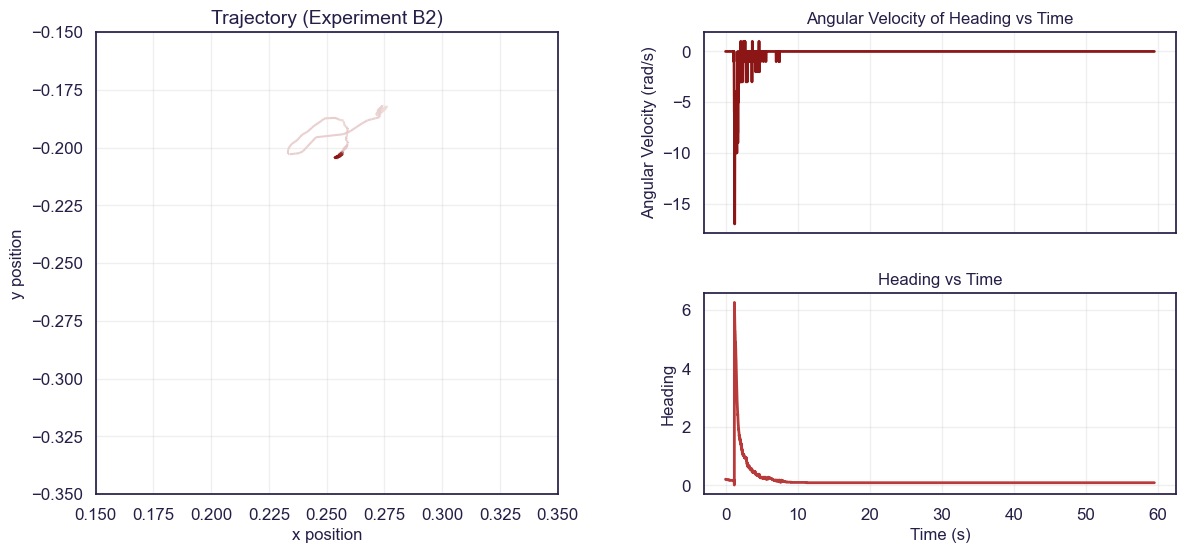

In [26]:
# Example: Plot a sample experiment
if len(combined_data) > 0:
    # Plot the first experiment as an example
    sample_id = combined_data['file_id'].iloc[0]
    print(f"Plotting experiment: {sample_id}")
    fig = plot_experiment('B2')
    plt.show()

In [11]:
def plot_analysis(experiment_id, combined_data=combined_data, recurrence_threshold_mult=0.1):
    """
    Plot FFT of heading and recurrence plot for heading.
    
    Parameters:
    -----------
    experiment_id : str
        The file ID of the experiment to plot (e.g., 'A1', 'B2', etc.)
    combined_data : pd.DataFrame
        The combined data dataframe (default: uses global combined_data)
    recurrence_threshold_mult : float
        Multiplier for recurrence plot threshold (default: 0.1)
        Threshold = recurrence_threshold_mult * std(heading)
    
    Returns:
    --------
    fig : matplotlib.figure.Figure
        The figure object
    """
    # Find the experiment
    exp_row = combined_data[combined_data['file_id'] == experiment_id]
    
    if len(exp_row) == 0:
        raise ValueError(f"Experiment ID '{experiment_id}' not found in combined_data")
    
    exp_row = exp_row.iloc[0]
    
    # Extract time series data
    time = np.array(exp_row['time'])
    x = np.array(exp_row['x'])
    y = np.array(exp_row['y'])
    heading = np.array(exp_row['heading'])
    
    # Remove NaN values
    valid_mask = ~(np.isnan(time) | np.isnan(x) | np.isnan(y) | np.isnan(heading))
    time_valid = time[valid_mask]
    x_valid = x[valid_mask]
    y_valid = y[valid_mask]
    heading_valid = heading[valid_mask]
    
    # Wrap heading to [-pi, pi]
    heading_valid = (heading_valid + np.pi) % (2 * np.pi) - np.pi
    
    # Create figure with two subplots
    fig = plt.figure(figsize=(12, 5))
    
    # 1. FFT of heading
    ax_fft = fig.add_subplot(1, 2, 1)
    
    # Compute FFT
    dt = np.mean(np.diff(time_valid)) if len(time_valid) > 1 else 0.01
    fft_vals = fft(heading_valid)
    fft_freq = fftfreq(len(heading_valid), dt)
    
    # Only plot positive frequencies
    positive_freq_mask = fft_freq > 0
    fft_freq_positive = fft_freq[positive_freq_mask]
    fft_power = np.abs(fft_vals[positive_freq_mask])
    
    # Find peak non-zero frequency
    if len(fft_power) > 0:
        peak_idx = np.argmax(fft_power)
        peak_freq = fft_freq_positive[peak_idx]
        peak_power = fft_power[peak_idx]
    else:
        peak_freq = 0
        peak_power = 0
    
    ax_fft.plot(fft_freq_positive, fft_power, linewidth=1.5, color=CARDINAL_RED)
    ax_fft.set_xlabel('Frequency (Hz)', fontsize=12)
    ax_fft.set_ylabel('Power', fontsize=12)
    ax_fft.set_title(f'FFT of Heading\nPeak: {peak_freq:.3f} Hz', fontsize=12)
    ax_fft.grid(True, alpha=0.3)
    ax_fft.set_xlim(0, min(10, fft_freq_positive.max()))  # Limit to reasonable frequency range
    
    # Mark the peak frequency
    if peak_freq > 0:
        ax_fft.plot(peak_freq, peak_power, 'o', color=CARDINAL_RED, markersize=10, label=f'Peak: {peak_freq:.3f} Hz')
        ax_fft.legend(fontsize=9)
    
    # 2. Recurrence plot for heading
    ax_recurrence = fig.add_subplot(1, 2, 2)
    
    # Compute recurrence matrix
    # Recurrence plot shows when the system returns to a similar state
    # We'll use a threshold based on standard deviation
    threshold = recurrence_threshold_mult * np.std(heading_valid)
    
    # Create recurrence matrix
    N = len(heading_valid)
    recurrence_matrix = np.zeros((N, N))
    
    for i in range(N):
        for j in range(N):
            if abs(heading_valid[i] - heading_valid[j]) < threshold:
                recurrence_matrix[i, j] = 1
    
    # Plot recurrence matrix
    im = ax_recurrence.imshow(recurrence_matrix, cmap='binary', origin='lower', 
                             aspect='auto', interpolation='nearest')
    ax_recurrence.set_xlabel('Time index j', fontsize=12)
    ax_recurrence.set_ylabel('Time index i', fontsize=12)
    ax_recurrence.set_title('Recurrence Plot (Heading)', fontsize=12)
    
    plt.tight_layout()
    
    return fig

Plotting analysis for experiment: A1


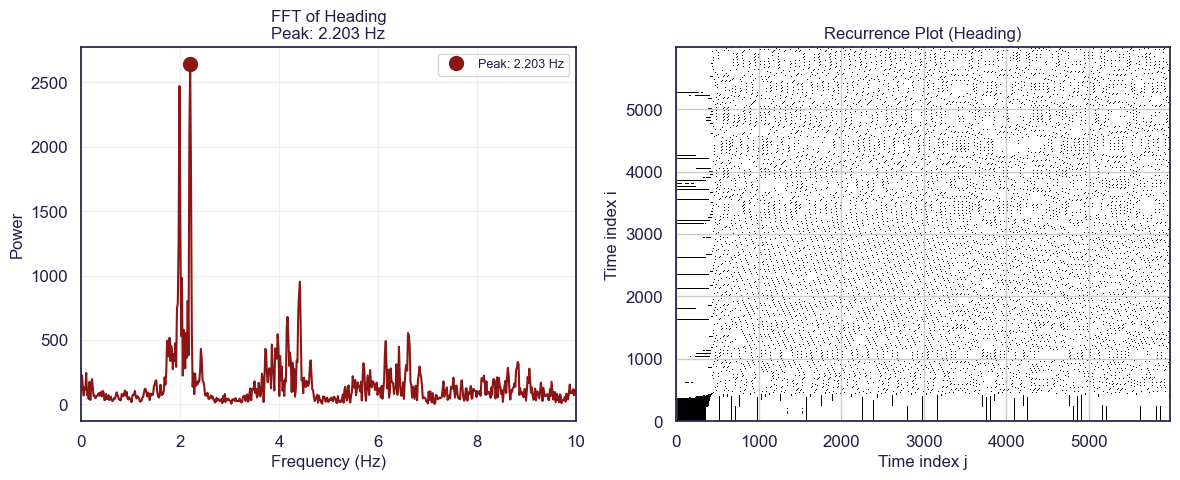

In [12]:
# Example: Plot analysis for a sample experiment
if len(combined_data) > 0:
    # Plot the first experiment as an example
    sample_id = combined_data['file_id'].iloc[0]
    print(f"Plotting analysis for experiment: {sample_id}")
    fig = plot_analysis('A8', recurrence_threshold_mult=0.1)
    plt.show()

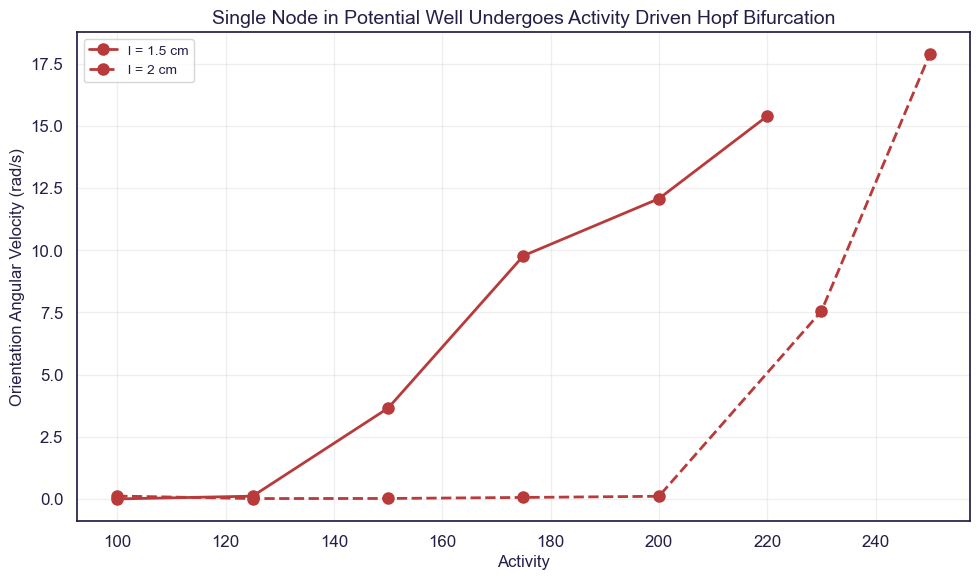

In [13]:
# Generate line plot: Drive vs Mean Angular Velocity
# Filter for specified conditions (thick wheel for main lines)
filtered_data = combined_data[
    (combined_data['X (grid lines)'] == 0) &
    (combined_data['Y (grid lines)'] == 1) &
    (combined_data['Gamma'] == 0) &
    (combined_data['Wheel'] == 'thick')
].copy()

# Also get thin wheel data for soft spring, short offset
filtered_data_thin = combined_data[
    (combined_data['X (grid lines)'] == 0) &
    (combined_data['Y (grid lines)'] == 1) &
    (combined_data['Gamma'] == 0) &
    (combined_data['Wheel'] == 'thin') &
    (combined_data['Spring'] == 'soft') &
    (combined_data['Offset'] == 'short')
].copy()

# Define the combinations we want to plot
combinations = [
    ('soft', 'short'),
    # ('extra soft', 'short'),
    ('soft', 'medium'),
    # ('extra soft', 'medium')
]

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Define colors, line styles, and markers based on spring, offset, and wheel type
# Short offset: solid, Medium offset: dashed
# Soft spring: circular markers, Extra soft spring: square markers
# Thin wheel: blue, Thick wheel: orange
def get_line_style(spring, offset, wheel='thick'):
    # Color: thin wheel is cardinal red, thick wheel is lighter cardinal
    if wheel == 'thin':
        color = CARDINAL_RED
    else:  # thick
        color = CARDINAL_RED_LIGHT
    
    # Line style: short offset is solid, medium offset is dashed
    if offset == 'short':
        linestyle = '-'
    elif offset == 'medium':
        linestyle = '--'
    else:
        linestyle = '-'
    
    # Marker: soft spring is circles, extra soft spring is squares
    if spring == 'soft':
        marker = 'o'
    elif spring == 'extra soft':
        marker = 's'
    else:
        marker = 'o'
    
    return color, linestyle, marker

for idx, (spring, offset) in enumerate(combinations):
    # Filter for this combination (thick wheel)
    combo_data = filtered_data[
        (filtered_data['Spring'] == spring) &
        (filtered_data['Offset'] == offset)
    ].copy()
    
    if len(combo_data) > 0:
        # Sort by Drive value
        combo_data = combo_data.sort_values('Drive')
        
        # Extract Drive and omega_mean
        drive_values = combo_data['Drive'].values
        omega_mean_values = np.abs(combo_data['omega_mean'].values)
        
        # Get color, line style, and marker
        color, linestyle, marker = get_line_style(spring, offset, wheel='thick')
        # Add line style to label
        line_style_text = 'solid' if linestyle == '-' else 'dashed'
        offl = '1.5' if offset == 'short' else '2'
        label = f'l = {offl} cm'
        
        # Plot line
        ax.plot(drive_values, omega_mean_values, 
               marker=marker, linewidth=2, markersize=8, 
               color=color, linestyle=linestyle, label=label)
    else:
        print(f"Warning: No data found for {spring} spring, {offset} offset")

# # Add thin wheel, soft spring, short offset line
# if len(filtered_data_thin) > 0:
#     thin_data = filtered_data_thin.sort_values('Drive')
#     drive_values_thin = thin_data['Drive'].values
#     omega_mean_values_thin = np.abs(thin_data['omega_mean'].values)
    
#     # Thin wheel, soft spring, short offset: blue, solid, circles
#     ax.plot(drive_values_thin, omega_mean_values_thin, 
#            marker='o', linewidth=2, markersize=8, 
#            color=CARDINAL_RED, linestyle='-', label='Thin Wheel, Soft Spring, Short Offset (solid)')
# else:
#     print("Warning: No data found for thin wheel, soft spring, short offset")

ax.set_xlabel('Activity', fontsize=12)
ax.set_ylabel('Orientation Angular Velocity (rad/s)', fontsize=12)
ax.set_title('Single Node in Potential Well Undergoes Activity Driven Hopf Bifurcation', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('march26_poster_1node_hopf.png', dpi=300)
plt.show()


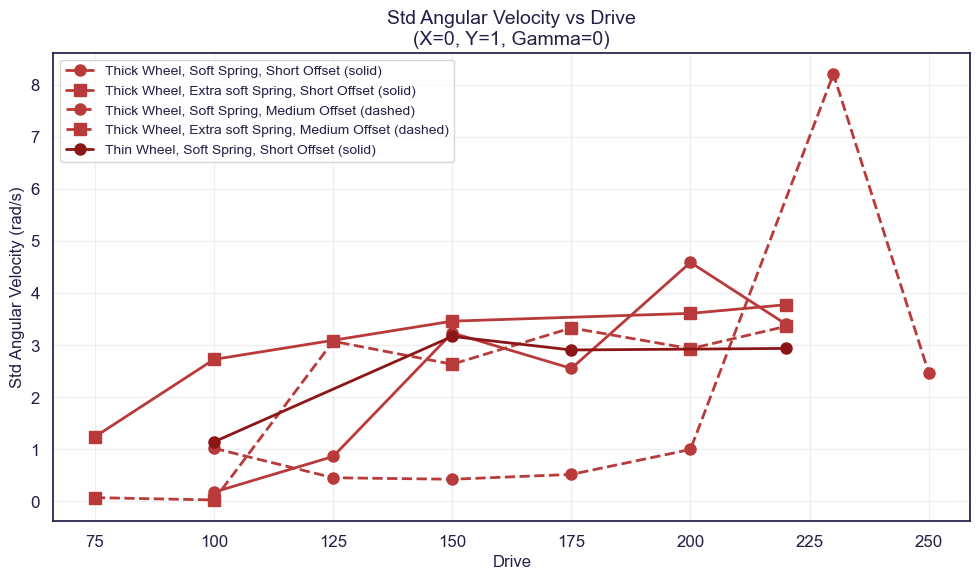

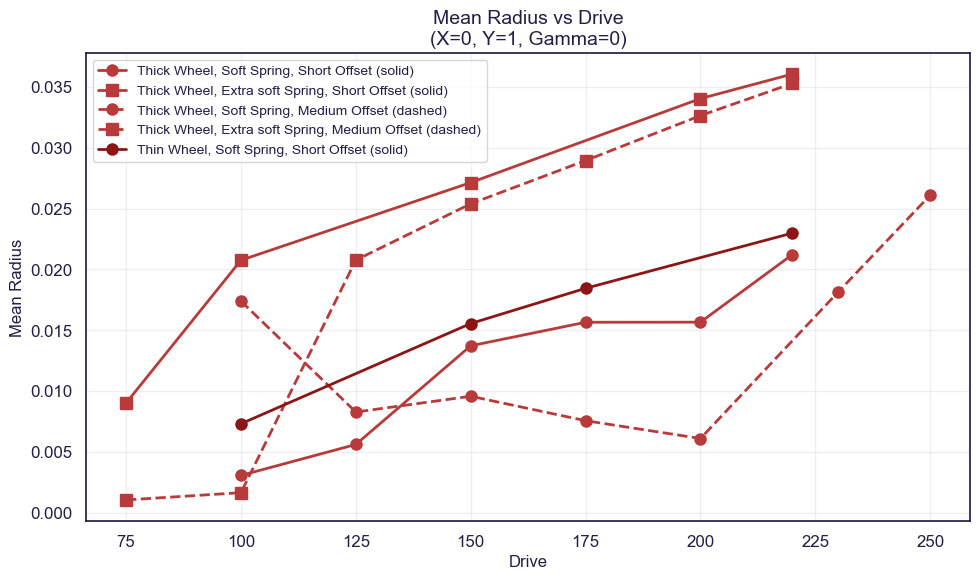

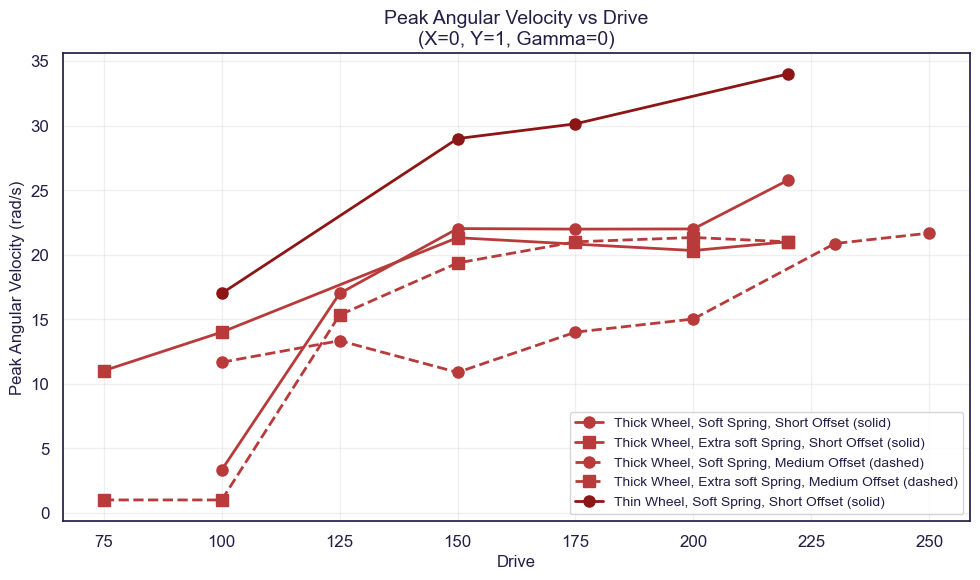

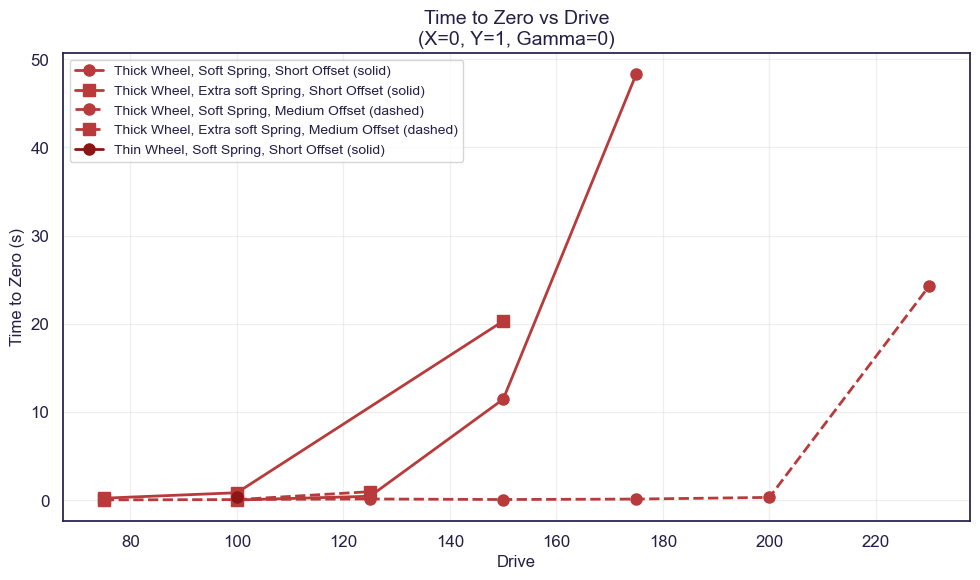

In [14]:
# Generate similar plots for all other metrics
metrics = [
    ('omega_std', 'Std Angular Velocity (rad/s)', 'Std Angular Velocity vs Drive'),
    ('mean_radius', 'Mean Radius', 'Mean Radius vs Drive'),
    ('peak_omega', 'Peak Angular Velocity (rad/s)', 'Peak Angular Velocity vs Drive'),
    ('time_to_zero', 'Time to Zero (s)', 'Time to Zero vs Drive')
]

# Filter for specified conditions (thick wheel for main lines)
filtered_data = combined_data[
    (combined_data['X (grid lines)'] == 0) &
    (combined_data['Y (grid lines)'] == 1) &
    (combined_data['Gamma'] == 0) &
    (combined_data['Wheel'] == 'thick')
].copy()

# Also get thin wheel data for soft spring, short offset
filtered_data_thin = combined_data[
    (combined_data['X (grid lines)'] == 0) &
    (combined_data['Y (grid lines)'] == 1) &
    (combined_data['Gamma'] == 0) &
    (combined_data['Wheel'] == 'thin') &
    (combined_data['Spring'] == 'soft') &
    (combined_data['Offset'] == 'short')
].copy()

# Define the combinations we want to plot
combinations = [
    ('soft', 'short'),
    ('extra soft', 'short'),
    ('soft', 'medium'),
    ('extra soft', 'medium')
]

# Define colors, line styles, and markers based on spring, offset, and wheel type
# Short offset: solid, Medium offset: dashed
# Soft spring: circular markers, Extra soft spring: square markers
# Thin wheel: blue, Thick wheel: orange
def get_line_style(spring, offset, wheel='thick'):
    # Color: thin wheel is cardinal red, thick wheel is lighter cardinal
    if wheel == 'thin':
        color = CARDINAL_RED
    else:  # thick
        color = CARDINAL_RED_LIGHT
    
    # Line style: short offset is solid, medium offset is dashed
    if offset == 'short':
        linestyle = '-'
    elif offset == 'medium':
        linestyle = '--'
    else:
        linestyle = '-'
    
    # Marker: soft spring is circles, extra soft spring is squares
    if spring == 'soft':
        marker = 'o'
    elif spring == 'extra soft':
        marker = 's'
    else:
        marker = 'o'
    
    return color, linestyle, marker

# Create plots for each metric
for metric_col, ylabel, title in metrics:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    for idx, (spring, offset) in enumerate(combinations):
        # Filter for this combination (thick wheel)
        combo_data = filtered_data[
            (filtered_data['Spring'] == spring) &
            (filtered_data['Offset'] == offset)
        ].copy()
        
        if len(combo_data) > 0:
            # Sort by Drive value
            combo_data = combo_data.sort_values('Drive')
            
            # Extract Drive and metric values
            drive_values = combo_data['Drive'].values
            metric_values = combo_data[metric_col].values
            
            # Handle inf values for time_to_zero
            if metric_col == 'time_to_zero':
                # Replace inf with NaN for plotting
                metric_values = np.where(np.isinf(metric_values), np.nan, metric_values)
            
            # Get color, line style, and marker
            color, linestyle, marker = get_line_style(spring, offset, wheel='thick')
            # Add line style to label
            line_style_text = 'solid' if linestyle == '-' else 'dashed'
            label = f'Thick Wheel, {spring.capitalize()} Spring, {offset.capitalize()} Offset ({line_style_text})'
            
            # Plot line
            ax.plot(drive_values, metric_values, 
                   marker=marker, linewidth=2, markersize=8, 
                   color=color, linestyle=linestyle, label=label)
        else:
            print(f"Warning: No data found for {spring} spring, {offset} offset")
    
    # Add thin wheel, soft spring, short offset line
    if len(filtered_data_thin) > 0:
        thin_data = filtered_data_thin.sort_values('Drive')
        drive_values_thin = thin_data['Drive'].values
        metric_values_thin = thin_data[metric_col].values
        
        # Handle inf values for time_to_zero
        if metric_col == 'time_to_zero':
            metric_values_thin = np.where(np.isinf(metric_values_thin), np.nan, metric_values_thin)
        
        # Thin wheel, soft spring, short offset: blue, solid, circles
        ax.plot(drive_values_thin, metric_values_thin, 
               marker='o', linewidth=2, markersize=8, 
               color=CARDINAL_RED, linestyle='-', label='Thin Wheel, Soft Spring, Short Offset (solid)')
    else:
        print(f"Warning: No data found for thin wheel, soft spring, short offset ({metric_col})")
    
    ax.set_xlabel('Drive', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(f'{title}\n(X=0, Y=1, Gamma=0)', fontsize=14)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

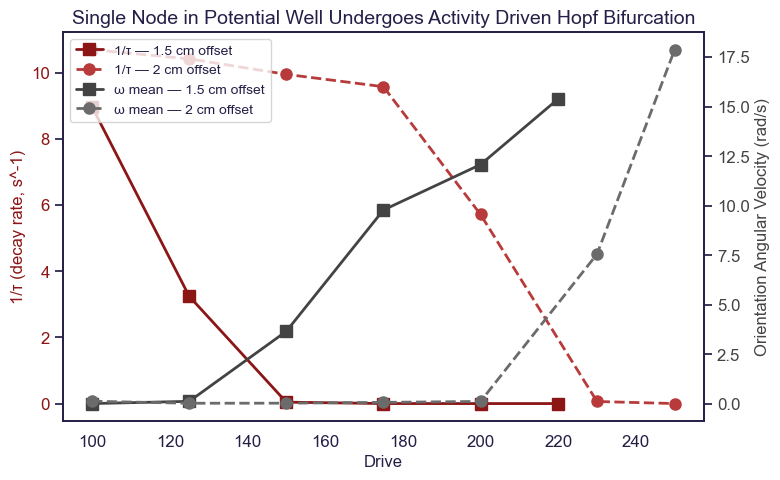

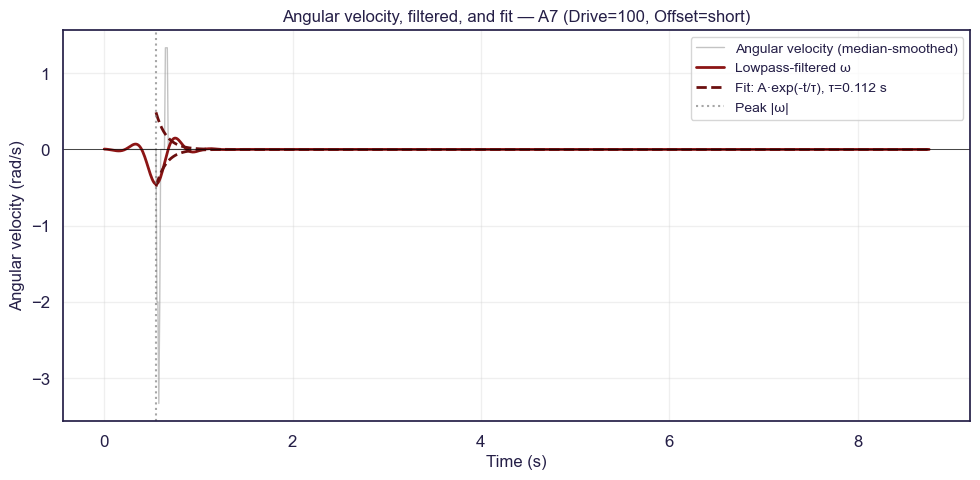

In [25]:
# Decay rate 1/τ vs Drive (Spring=soft, Offset in [short, medium])
# For each heading trajectory: lowpass-filter omega, fit A*exp(-t/tau) from peak onward.
# Plot 1/τ (decay rate); poor fits (R² < 0.3) are plotted as 0.

def exp_decay(t, A, tau):
    """Exponential decay asymptotically to 0: y = A * exp(-t/tau)"""
    return A * np.exp(-t / tau)

def plot_omega_filtered_and_fit(experiment_id, combined_data=combined_data, cutoff_hz=3, order=4, ax=None):
    """
    Plot angular velocity (median-smoothed), lowpass-filtered angular velocity,
    and fitted exponential decay for an experiment.
    experiment_id: file_id string (e.g. '090226_A1')
    Returns (fig, ax) or (None, None) if experiment not found or fit fails.
    """
    exp_row = combined_data[combined_data['file_id'] == experiment_id]
    if len(exp_row) == 0:
        print(f"Experiment {experiment_id} not found.")
        return None, None

    row = exp_row.iloc[0]
    time_arr = np.array(row['time'])
    heading_arr = np.array(row['heading'])
    if len(time_arr) < 10 or len(heading_arr) < 10:
        print(f"Insufficient data for {experiment_id}")
        return None, None

    heading_centered = (heading_arr + np.pi) % (2 * np.pi) - np.pi
    heading_unwrapped = np.unwrap(heading_centered)
    dtheta = np.diff(heading_unwrapped)
    dt = np.diff(time_arr)
    dt[dt < 1e-6] = 1e-6
    omega_raw = dtheta / dt
    omega_med = pd.Series(omega_raw).rolling(window=5, center=True, min_periods=1).median().values

    fs = 1.0 / np.nanmean(dt)
    nyq = fs / 2
    cutoff_norm = min(cutoff_hz / nyq, 0.99)
    b, a = butter(order, cutoff_norm, btype='low')
    omega_filt = filtfilt(b, a, np.nan_to_num(omega_med, nan=np.nanmean(omega_med)))

    time_valid = time_arr[:-1]
    omega_abs = np.abs(omega_filt)
    peak_idx = np.argmax(omega_abs)

    t_rel = time_valid[peak_idx:] - time_valid[peak_idx]
    y_decay = omega_abs[peak_idx:]
    valid = (t_rel >= 0) & np.isfinite(y_decay) & (y_decay > 0)
    t_fit = t_rel[valid]
    y_fit = y_decay[valid]

    if len(t_fit) < 5:
        print(f"Not enough decay points to fit for {experiment_id}")
        # still plot omega and omega_filt
        A_fit, tau_fit = None, None
    else:
        try:
            popt, _ = curve_fit(exp_decay, t_fit, y_fit, p0=[y_fit[0], 0.5], bounds=([0, 0.01], [np.inf, 50]))
            A_fit, tau_fit = popt
        except Exception:
            A_fit, tau_fit = None, None

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 5))
    else:
        fig = ax.figure

    ax.plot(time_valid, omega_med, alpha=0.5, color='#888888', linewidth=1, label='Angular velocity (median-smoothed)')
    ax.plot(time_valid, omega_filt, color=CARDINAL_RED, linewidth=2, label='Lowpass-filtered ω')
    if A_fit is not None and tau_fit is not None:
        t_plot = time_valid[peak_idx:]
        fit_vals = A_fit * np.exp(-(t_plot - time_valid[peak_idx]) / tau_fit)
        ax.plot(t_plot, fit_vals, '--', color=CARDINAL_RED_DARK, linewidth=2, label=f'Fit: A·exp(-t/τ), τ={tau_fit:.3f} s')
        ax.plot(t_plot, -fit_vals, '--', color=CARDINAL_RED_DARK, linewidth=2)

    ax.axvline(time_valid[peak_idx], color='gray', linestyle=':', alpha=0.7, label='Peak |ω|')
    ax.set_xlabel('Time (s)', fontsize=12)
    ax.set_ylabel('Angular velocity (rad/s)', fontsize=12)
    ax.set_title(f'Angular velocity, filtered, and fit — {experiment_id} (Drive={row["Drive"]}, Offset={row["Offset"]})', fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='k', linewidth=0.5)
    plt.tight_layout()
    return fig, ax

# Filter: Spring=soft, Offset in [short, medium], other params as before
tau_data = combined_data[
    (combined_data['X (grid lines)'] == 0) &
    (combined_data['Y (grid lines)'] == 1) &
    (combined_data['Gamma'] == 0) &
    (combined_data['Wheel'] == 'thick') &
    (combined_data['Spring'] == 'soft') &
    (combined_data['Offset'].isin(['short', 'medium']))
].copy()

cutoff_hz = 3
order = 4

tau_results = []  # list of (Drive, Offset, inv_tau) where inv_tau = 1/tau, or 0 if fit is bad
R2_THRESHOLD = 0.3  # fits with R² below this are reported as inv_tau = 0

for idx, row in tau_data.iterrows():
    try:
        time_arr = np.array(row['time'])
        heading_arr = np.array(row['heading'])
        if len(time_arr) < 10 or len(heading_arr) < 10:
            continue

        heading_centered = (heading_arr + np.pi) % (2 * np.pi) - np.pi
        heading_unwrapped = np.unwrap(heading_centered)
        dtheta = np.diff(heading_unwrapped)
        dt = np.diff(time_arr)
        dt[dt < 1e-6] = 1e-6
        omega_raw = dtheta / dt
        omega_med = pd.Series(omega_raw).rolling(window=5, center=True, min_periods=1).median().values

        fs = 1.0 / np.nanmean(dt)
        nyq = fs / 2
        cutoff_norm = min(cutoff_hz / nyq, 0.99)
        b, a = butter(order, cutoff_norm, btype='low')
        omega_filt = filtfilt(b, a, np.nan_to_num(omega_med, nan=np.nanmean(omega_med)))

        time_valid = time_arr[:-1]
        omega_abs = np.abs(omega_filt)
        peak_idx = np.argmax(omega_abs)

        t_rel = time_valid[peak_idx:] - time_valid[peak_idx]
        y_decay = omega_abs[peak_idx:]
        valid = (t_rel >= 0) & np.isfinite(y_decay) & (y_decay > 0)
        t_fit = t_rel[valid]
        y_fit = y_decay[valid]
        if len(t_fit) < 5:
            continue

        p0 = [y_fit[0], 0.5]
        try:
            popt, _ = curve_fit(exp_decay, t_fit, y_fit, p0=p0, bounds=([0, 0.01], [np.inf, 50]))
            A_fit, tau_fit = popt
            y_pred = exp_decay(t_fit, A_fit, tau_fit)
            ss_res = np.sum((y_fit - y_pred) ** 2)
            ss_tot = np.sum((y_fit - np.mean(y_fit)) ** 2)
            r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0
            inv_tau = (1.0 / tau_fit) if r2 >= R2_THRESHOLD else 0.0
            tau_results.append((row['Drive'], row['Offset'], inv_tau))
        except Exception:
            pass
    except Exception:
        pass

if tau_results:
    df_tau = pd.DataFrame(tau_results, columns=['Drive', 'Offset', 'inv_tau'])
    fig, ax = plt.subplots(figsize=(8, 5))
    for offset in ['short', 'medium']:
        sub = df_tau[df_tau['Offset'] == offset].sort_values('Drive')
        if len(sub) > 0:
            ls = '-' if offset == 'short' else '--'
            marker = 's' if offset == 'short' else 'o'  # short: square, medium: round
            offl = '1.5' if offset == 'short' else '2'
            ax.plot(sub['Drive'], sub['inv_tau'], marker=marker, linewidth=2, markersize=8, linestyle=ls,
                    label=f'1/τ — {offl} cm offset', color=CARDINAL_RED if offset == 'short' else CARDINAL_RED_LIGHT)

    ax2 = ax.twinx()
    # Add omega_mean data (Hopf bifurcation) from same filter
    for offset in ['short', 'medium']:
        sub = tau_data[tau_data['Offset'] == offset].sort_values('Drive')
        if len(sub) > 0:
            omega_by_drive = sub.groupby('Drive')['omega_mean'].mean().reset_index()
            ls = '-' if offset == 'short' else '--'
            marker = 's' if offset == 'short' else 'o'  # short: square, medium: round
            color = '#434343' if offset == 'short' else '#6B6B6B'
            offl = '1.5' if offset == 'short' else '2'
            ax2.plot(omega_by_drive['Drive'], np.abs(omega_by_drive['omega_mean']), marker=marker,
                     linewidth=2, markersize=8, linestyle=ls, label=f'ω mean — {offl} cm offset', color=color)

    ax.set_xlabel('Drive', fontsize=12)
    ax.set_ylabel('1/τ (decay rate, s^-1)', fontsize=12, color=CARDINAL_RED)
    ax.tick_params(axis='y', labelcolor=CARDINAL_RED)
    ax2.set_ylabel('Orientation Angular Velocity (rad/s)', fontsize=12, color='#434343')
    ax2.tick_params(axis='y', labelcolor='#434343')
    ax.set_title('Single Node in Potential Well Undergoes Activity Driven Hopf Bifurcation', fontsize=14)
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=10, loc='upper left')
    ax.grid(False)
    ax2.grid(False)
    plt.tight_layout()
    plt.savefig('march26_poster_1node_hopf2.png', dpi=300)
    plt.show()
else:
    print("No successful fits for tau vs Drive.")

# Example: plot omega, filtered omega, and fit for first experiment in tau_data
if len(tau_data) > 0:
    first_id = tau_data.iloc[0]['file_id']
    plot_omega_filtered_and_fit(first_id)

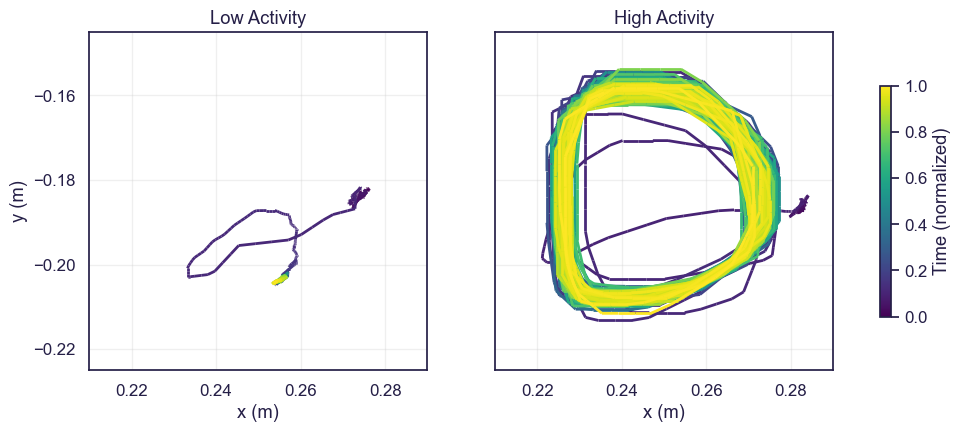

In [47]:
# x/y trajectory plots for B2 and B25, colored by time
from matplotlib.ticker import MaxNLocator

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
ids = ['B2', 'B25']
n_ticks = 5

for ax, exp_id in zip(axes, ids):
    exp_row = combined_data[combined_data['file_id'] == exp_id]
    if len(exp_row) == 0:
        ax.text(0.5, 0.5, f'{exp_id} not found', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(exp_id)
        continue

    row = exp_row.iloc[0]
    x = np.array(row['x'])
    y = np.array(row['y'])
    time = np.array(row['time'])
    t_norm = (time - time.min()) / (time.max() - time.min() + 1e-9)

    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = LineCollection(segments, cmap='viridis', array=t_norm[:], linewidth=2)
    ax.add_collection(lc)
    pad = 0.05 * (max(x.max() - x.min(), y.max() - y.min()) or 1)
    ax.set_xlim(.21, .29)
    ax.set_ylim(-.225, -.145)
    ax.set_aspect('equal')
    ax.set_xlabel('x (m)')
    if exp_id == 'B2':
        ax.set_ylabel('y (m)')
    tit = 'Low' if exp_id == 'B2' else 'High'
    ax.set_title(f'{tit} Activity')
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=n_ticks))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=n_ticks))

cbar = fig.colorbar(lc, ax=axes, shrink=0.6, label='Time (normalized)')
# plt.tight_layout()
plt.show()

In [34]:
axes[1]

<Axes: title={'center': 'B25 trajectory'}, xlabel='x', ylabel='y'>